## Préparation de l'environnement et chargement des données

Nous allons commencer par importer les bibliothèques nécessaires et définir le jeu de données pour nos exercices.

In [22]:
# Importation des bibliothèques nécessaires
import pandas as pd
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Téléchargement des ressources NLTK nécessaires
# Ces téléchargements ne sont nécessaires qu'une seule fois.
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger') # Pour le POS tagging plus tard
nltk.download('punkt_tab') # Ajouté pour résoudre l'erreur LookupError avec word_tokenize
nltk.download('averaged_perceptron_tagger_eng') # Ajouté pour résoudre l'erreur LookupError pour le POS tagging
nltk.download('tagsets') # Déjà présent mais je le mentionne pour être complet
nltk.download('tagsets_json') # Ajouté pour résoudre l'erreur LookupError avec nltk.help.upenn_tagset

# Chargement du modèle spaCy pour le NER
# Assurez-vous d'avoir ce modèle installé : python -m spacy download en_core_web_sm
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Téléchargement du modèle spaCy 'en_core_web_sm'. Ceci peut prendre quelques instants...")
    spacy.cli.download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

# Définition du jeu de données
data = {
    'Review': [
        'At McDonald\'s the food was ok and the service was bad.',
        'I would not recommend this Japanese restaurant to anyone.',
        'I loved this restaurant when I traveled to Thailand last summer.',
        'The menu of Loving has a wide variety of options.',
        'The staff was friendly and helpful at Google\'s employees restaurant.',
        'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
        'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
        'The sushi at Sushi Express is always fresh and flavorful.',
        'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
        'The dessert selection at Sweet Treats is to die for!'
    ]
}

# Création du DataFrame pandas
df_raw = pd.DataFrame(data)
print("Voici les données brutes initiales :")
display(df_raw)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package tagse

Voici les données brutes initiales :


,Review
0,At McDonald's the food was ok and the service ...
1,I would not recommend this Japanese restaurant...
2,I loved this restaurant when I traveled to Tha...
3,The menu of Loving has a wide variety of options.
4,The staff was friendly and helpful at Google's...
5,"The ambiance at Bella Italia is amazing, and t..."
6,I had a terrible experience at Pizza Hut. The ...
7,The sushi at Sushi Express is always fresh and...
8,The steakhouse on Main Street has a cozy atmos...
9,The dessert selection at Sweet Treats is to di...


## Exercice 1: Exploration de la prétraitement de texte, des tags NER et POS

### 1. Création de la fonction `preprocess_text()`

Cette fonction prendra en charge la mise en minuscule, la tokenisation, la suppression de la ponctuation, la suppression des mots vides (stopwords) et la lemmatisation du texte. Nous allons ensuite l'appliquer à notre jeu de données.

In [23]:
def preprocess_text(text):
    # Convertir en minuscules
    text = text.lower()

    # Tokeniser le texte (le diviser en mots)
    tokens = nltk.word_tokenize(text)

    # Supprimer la ponctuation et les caractères non alphabétiques
    # string.punctuation contient tous les signes de ponctuation courants
    tokens = [word for word in tokens if word.isalpha()]

    # Supprimer les mots vides (stopwords)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Appliquer la lemmatisation
    # La lemmatisation réduit les mots à leur forme de base (lemme)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Reconstruire le texte prétraité
    preprocessed_text = ' '.join(tokens)
    return preprocessed_text

# Application de la fonction de prétraitement au DataFrame
print("Application du prétraitement sur la première critique pour démonstration :")
print(preprocess_text(df_raw['Review'][0]))

Application du prétraitement sur la première critique pour démonstration :
mcdonald food ok service bad


### 2. Création d'un nouveau jeu de données avec le texte nettoyé

Il est souvent utile de conserver les données brutes tout en ayant une colonne pour le texte prétraité. Nous allons ajouter une nouvelle colonne à notre DataFrame pour le texte nettoyé.

In [24]:
# Créer une copie du DataFrame brut pour y ajouter le texte prétraité
df_preprocessed = df_raw.copy()

# Appliquer la fonction preprocess_text à la colonne 'Review' et stocker le résultat dans une nouvelle colonne 'Cleaned_Review'
df_preprocessed['Cleaned_Review'] = df_preprocessed['Review'].apply(preprocess_text)

print("Voici le DataFrame avec la colonne de texte nettoyé :")
display(df_preprocessed[['Review', 'Cleaned_Review']].head())

Voici le DataFrame avec la colonne de texte nettoyé :


,Review,Cleaned_Review
0,At McDonald's the food was ok and the service ...,mcdonald food ok service bad
1,I would not recommend this Japanese restaurant...,would recommend japanese restaurant anyone
2,I loved this restaurant when I traveled to Tha...,loved restaurant traveled thailand last summer
3,The menu of Loving has a wide variety of options.,menu loving wide variety option
4,The staff was friendly and helpful at Google's...,staff friendly helpful google employee restaurant


### 3. Création de la fonction `perform_ner()` pour la reconnaissance d'entités nommées (NER)

Cette fonction utilisera la bibliothèque `spaCy` pour identifier et étiqueter les entités nommées (personnes, organisations, lieux, etc.) dans le texte. Nous allons l'appliquer aux données prétraitées.

In [25]:
def perform_ner(text):
    # Traiter le texte avec le modèle spaCy chargé (nlp)
    doc = nlp(text)

    # Extraire les entités et leurs labels
    # entity.text est le texte de l'entité, entity.label_ est le type d'entité (ORG, GPE, DATE, etc.)
    entities = [(entity.text, entity.label_) for entity in doc.ents]
    return entities

# Application de la fonction perform_ner à la colonne 'Cleaned_Review' (texte prétraité)
df_preprocessed['NER_Preprocessed'] = df_preprocessed['Cleaned_Review'].apply(perform_ner)

# Affichage des résultats pour le texte prétraité
print("Voici le DataFrame avec les entités nommées (NER) extraites du texte prétraité :")
display(df_preprocessed[['Cleaned_Review', 'NER_Preprocessed']].head())

# Application de la fonction perform_ner à la colonne 'Review' (texte brut) pour comparaison
df_preprocessed['NER_Raw'] = df_preprocessed['Review'].apply(perform_ner)

# Affichage des résultats pour le texte brut
print("\nVoici le DataFrame avec les entités nommées (NER) extraites du texte brut pour comparaison :")
display(df_preprocessed[['Review', 'NER_Raw']].head())

Voici le DataFrame avec les entités nommées (NER) extraites du texte prétraité :


,Cleaned_Review,NER_Preprocessed
0,mcdonald food ok service bad,"[(mcdonald food ok service, ORG)]"
1,would recommend japanese restaurant anyone,"[(japanese, NORP)]"
2,loved restaurant traveled thailand last summer,"[(thailand, GPE), (last summer, DATE)]"
3,menu loving wide variety option,[]
4,staff friendly helpful google employee restaurant,"[(google, ORG)]"



Voici le DataFrame avec les entités nommées (NER) extraites du texte brut pour comparaison :


,Review,NER_Raw
0,At McDonald's the food was ok and the service ...,"[(McDonald, ORG)]"
1,I would not recommend this Japanese restaurant...,"[(Japanese, NORP)]"
2,I loved this restaurant when I traveled to Tha...,"[(Thailand, GPE), (last summer, DATE)]"
3,The menu of Loving has a wide variety of options.,"[(Loving, GPE)]"
4,The staff was friendly and helpful at Google's...,"[(Google, ORG)]"


### 4. Création de la fonction `perform_pos_tagging()` pour le Part-Of-Speech (POS) tagging

Cette fonction utilisera `nltk` pour attribuer une étiquette grammaticale (nom, verbe, adjectif, etc.) à chaque mot du texte.

In [26]:
def perform_pos_tagging(text):
    # Tokeniser le texte en mots
    tokens = nltk.word_tokenize(text)
    # Effectuer le POS tagging
    # nltk.pos_tag retourne une liste de tuples (mot, tag_pos)
    pos_tags = nltk.pos_tag(tokens)
    return pos_tags

# Application de la fonction perform_pos_tagging à la colonne 'Cleaned_Review' (texte prétraité)
df_preprocessed['POS_Preprocessed'] = df_preprocessed['Cleaned_Review'].apply(perform_pos_tagging)

# Affichage des résultats pour le texte prétraité
print("Voici le DataFrame avec les tags POS extraits du texte prétraité :")
display(df_preprocessed[['Cleaned_Review', 'POS_Preprocessed']].head())

# Application de la fonction perform_pos_tagging à la colonne 'Review' (texte brut) pour comparaison
df_preprocessed['POS_Raw'] = df_preprocessed['Review'].apply(perform_pos_tagging)

# Affichage des résultats pour le texte brut
print("\nVoici le DataFrame avec les tags POS extraits du texte brut pour comparaison :")
display(df_preprocessed[['Review', 'POS_Raw']].head())

Voici le DataFrame avec les tags POS extraits du texte prétraité :


,Cleaned_Review,POS_Preprocessed
0,mcdonald food ok service bad,"[(mcdonald, NNS), (food, NN), (ok, JJ), (servi..."
1,would recommend japanese restaurant anyone,"[(would, MD), (recommend, VB), (japanese, JJ),..."
2,loved restaurant traveled thailand last summer,"[(loved, VBN), (restaurant, NN), (traveled, VB..."
3,menu loving wide variety option,"[(menu, NN), (loving, VBG), (wide, JJ), (varie..."
4,staff friendly helpful google employee restaurant,"[(staff, NN), (friendly, RB), (helpful, JJ), (..."



Voici le DataFrame avec les tags POS extraits du texte brut pour comparaison :


,Review,POS_Raw
0,At McDonald's the food was ok and the service ...,"[(At, IN), (McDonald, NNP), ('s, POS), (the, D..."
1,I would not recommend this Japanese restaurant...,"[(I, PRP), (would, MD), (not, RB), (recommend,..."
2,I loved this restaurant when I traveled to Tha...,"[(I, PRP), (loved, VBD), (this, DT), (restaura..."
3,The menu of Loving has a wide variety of options.,"[(The, DT), (menu, NN), (of, IN), (Loving, NNP..."
4,The staff was friendly and helpful at Google's...,"[(The, DT), (staff, NN), (was, VBD), (friendly..."


### 5. Analyse des sorties NER et POS

Pour mieux comprendre la signification des tags POS, nous pouvons utiliser l'outil `nltk` pour afficher les descriptions des tags.

In [27]:
print("Explication de quelques tags POS (Part-Of-Speech) courants :")
nltk.download('tagsets') # Assurez-vous que cela est téléchargé, bien que fait en début de notebook
nltk.help.upenn_tagset('NN')   # Nom singulier
nltk.help.upenn_tagset('NNS')  # Nom pluriel
nltk.help.upenn_tagset('JJ')   # Adjectif
nltk.help.upenn_tagset('VB')   # Verbe (forme de base)
nltk.help.upenn_tagset('VBD')  # Verbe (passé simple)
nltk.help.upenn_tagset('RB')   # Adverbe
nltk.help.upenn_tagset('PRP')  # Pronom personnel

print("\nAnalyse comparative des tags NER et POS sur les données brutes vs prétraitées :")
print("Il est intéressant de noter comment le prétraitement (mise en minuscule, suppression de ponctuation et stopwords, lemmatisation) affecte la détection des entités nommées et l'étiquetage POS.")
print("Par exemple, la mise en minuscule peut parfois affecter la reconnaissance de noms propres par spaCy si le modèle n'est pas robuste aux variations de casse.")
print("La suppression des stopwords peut rendre le texte plus concis pour le POS tagging en se concentrant sur les mots porteurs de sens.")
print("La lemmatisation ramène les mots à leur forme de base, ce qui peut standardiser les tags POS pour les verbes ou noms conjugués/pluriels.")

Explication de quelques tags POS (Part-Of-Speech) courants :
NN: noun, common, singular or mass
    common-carrier cabbage knuckle-duster Casino afghan shed thermostat
    investment slide humour falloff slick wind hyena override subhumanity
    machinist ...
NNS: noun, common, plural
    undergraduates scotches bric-a-brac products bodyguards facets coasts
    divestitures storehouses designs clubs fragrances averages
    subjectivists apprehensions muses factory-jobs ...
JJ: adjective or numeral, ordinal
    third ill-mannered pre-war regrettable oiled calamitous first separable
    ectoplasmic battery-powered participatory fourth still-to-be-named
    multilingual multi-disciplinary ...
VB: verb, base form
    ask assemble assess assign assume atone attention avoid bake balkanize
    bank begin behold believe bend benefit bevel beware bless boil bomb
    boost brace break bring broil brush build ...
VBD: verb, past tense
    dipped pleaded swiped regummed soaked tidied convened halt

[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!


In [28]:
# Installation de la bibliothèque gensim
!pip install gensim
print("La bibliothèque gensim a été installée.")

La bibliothèque gensim a été installée.


## Exercice 2: Visualisation des Word Embeddings

### 1. Création des Word Embeddings avec Word2Vec

Nous allons utiliser le modèle Word2Vec de la bibliothèque `gensim` pour convertir nos mots en vecteurs numériques. Cela nous permettra de capturer les relations sémantiques entre les mots. Nous utiliserons le texte **prétraité et tokenisé** pour entraîner ce modèle.

In [29]:
from gensim.models import Word2Vec

# Pour Word2Vec, nous avons besoin d'une liste de listes de mots (phrases tokenisées)
# Nous allons re-tokeniser notre colonne 'Cleaned_Review' pour cela.
# Si 'Cleaned_Review' est déjà une chaîne, nous devons la re-tokeniser.

# Assurez-vous que la colonne 'Cleaned_Review' est bien une chaîne de caractères à tokeniser
def tokenize_for_w2v(text):
    # Gérer le cas où le texte est vide ou non une chaîne
    if not isinstance(text, str) or not text.strip():
        return []
    return text.split() # Une simple division par espace devrait suffire pour le texte prétraité

df_preprocessed['Tokenized_Review'] = df_preprocessed['Cleaned_Review'].apply(tokenize_for_w2v)

# Filtrer les lignes avec des listes de tokens vides avant d'entraîner Word2Vec
# Sinon, Word2Vec pourrait échouer si toutes les phrases sont vides
corpus = df_preprocessed[df_preprocessed['Tokenized_Review'].apply(len) > 0]['Tokenized_Review'].tolist()

# Afficher un exemple de tokens pour Word2Vec
print("Exemple de revue tokenisée pour Word2Vec :")
if corpus:
    print(corpus[0])
else:
    print("Aucun texte tokenisé disponible pour l'entraînement.")

# Entraîner le modèle Word2Vec
# `sentences`: une liste de listes de mots
# `vector_size`: la dimension des vecteurs (ex: 100, 300)
# `window`: la taille de la fenêtre contextuelle
# `min_count`: ignore tous les mots dont la fréquence est inférieure à ce seuil
# `sg`: 0 pour CBOW, 1 pour Skip-gram (Skip-gram est souvent meilleur pour de petits datasets)

# Entraîner le modèle Word2Vec seulement si le corpus n'est pas vide
if corpus:
    model_w2v = Word2Vec(
        sentences=corpus,
        vector_size=100,  # Dimension des vecteurs (par exemple, 100)
        window=5,         # Fenêtre de contexte de 5 mots de chaque côté
        min_count=1,      # Inclut tous les mots apparaissant au moins 1 fois
        sg=0,             # Utilise l'architecture CBOW (Continuous Bag of Words)
        epochs=10         # Nombre d'itérations d'apprentissage
    )

    print("\nModèle Word2Vec entraîné avec succès.")

    # Imprimer les dimensions de l'objet Word2Vec
    print(f"\nDimensions du modèle Word2Vec :")
    print(f"Taille du vocabulaire : {len(model_w2v.wv)}")
    print(f"Dimension des vecteurs de mots : {model_w2v.vector_size}")

    print("\nAnalyse des dimensions du Word2Vec :")
    print(f"La taille du vocabulaire ({len(model_w2v.wv)}) représente le nombre de mots uniques pour lesquels le modèle a créé un vecteur.")
    print(f"La dimension des vecteurs de mots ({model_w2v.vector_size}) signifie que chaque mot est représenté par un tableau de {model_w2v.vector_size} nombres. Ces nombres sont des caractéristiques latentes qui encodent le sens sémantique et les relations contextuelles du mot.")
    print("Plus la dimension est grande, plus le modèle peut capturer de nuances, mais cela augmente aussi la complexité de calcul et la quantité de données nécessaire pour un entraînement efficace.")

    # Exemple d'accès à un vecteur de mot
    print("\nExemple de vecteur pour le mot 'food' :")
    if 'food' in model_w2v.wv:
        print(model_w2v.wv['food'][:10]) # Affiche les 10 premières valeurs du vecteur
    else:
        print("Le mot 'food' n'est pas dans le vocabulaire.")
else:
    print("Le corpus est vide, le modèle Word2Vec n'a pas pu être entraîné.")

Exemple de revue tokenisée pour Word2Vec :
['mcdonald', 'food', 'ok', 'service', 'bad']

Modèle Word2Vec entraîné avec succès.

Dimensions du modèle Word2Vec :
Taille du vocabulaire : 55
Dimension des vecteurs de mots : 100

Analyse des dimensions du Word2Vec :
La taille du vocabulaire (55) représente le nombre de mots uniques pour lesquels le modèle a créé un vecteur.
La dimension des vecteurs de mots (100) signifie que chaque mot est représenté par un tableau de 100 nombres. Ces nombres sont des caractéristiques latentes qui encodent le sens sémantique et les relations contextuelles du mot.
Plus la dimension est grande, plus le modèle peut capturer de nuances, mais cela augmente aussi la complexité de calcul et la quantité de données nécessaire pour un entraînement efficace.

Exemple de vecteur pour le mot 'food' :
[-0.0033387  -0.00689198  0.00649541  0.00938755  0.00827288 -0.00853417
  0.00504777  0.0051      0.00562876 -0.00832465]


### 2. Création de la fonction `plot_word_embeddings()`

Pour visualiser les *word embeddings* qui sont en 100 dimensions, nous devons d'abord réduire leur dimensionnalité à 2 dimensions. Nous utiliserons la **PCA (Analyse en Composantes Principales)** pour cela. Ensuite, nous tracerons ces points dans un nuage de points et annoterons chaque point avec le mot correspondant.

Visualisation des Word Embeddings...


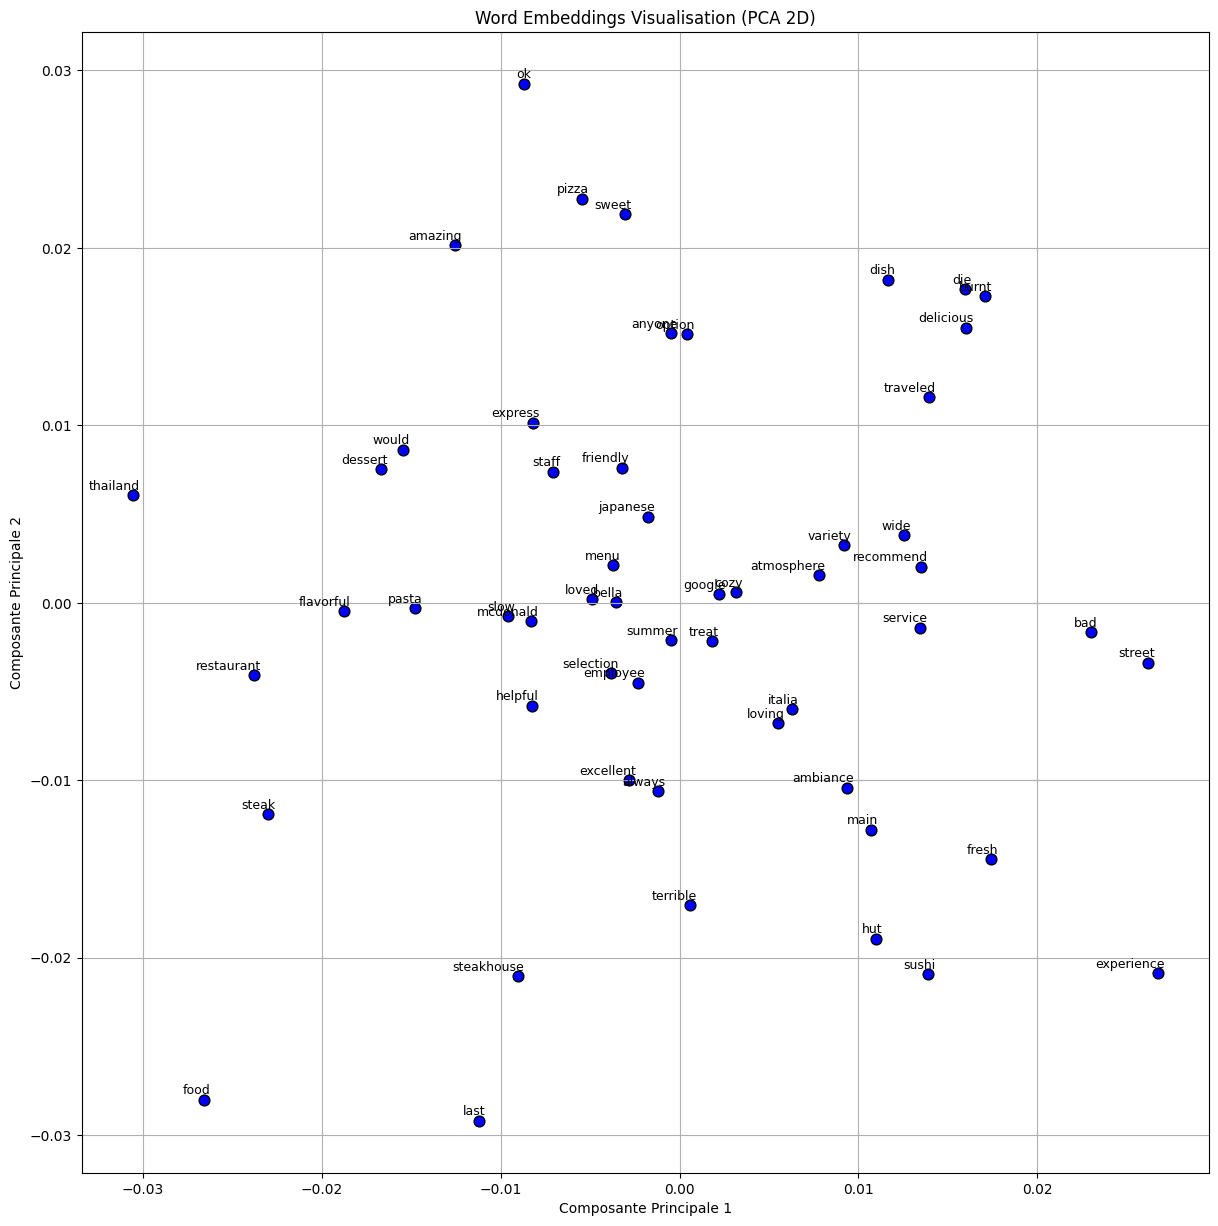


Analyse :
Sur ce graphique, nous cherchons à voir si les mots sémantiquement similaires sont regroupés. Étant donné la petite taille de notre jeu de données, les relations peuvent ne pas être aussi claires ou parfaites que dans un modèle entraîné sur un très grand corpus.
Si des mots liés comme 'food' et 'restaurant' ou 'bad' et 'terrible' apparaissent proches, cela indique que le modèle a bien capturé certaines relations.
Les raisons possibles d'un regroupement non idéal pourraient être : la petite taille du corpus, les paramètres du modèle Word2Vec (taille du vecteur, fenêtre, architecture), et la nature même de la réduction de dimensionnalité qui peut perdre certaines informations.


In [30]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

def plot_word_embeddings(model):
    # Vérifier si le modèle a été entraîné
    if not hasattr(model, 'wv'):
        print("Le modèle Word2Vec n'est pas entraîné ou ne contient pas de WordVectors.")
        return

    # Obtenir tous les mots et leurs vecteurs
    words = list(model.wv.index_to_key)
    vectors = model.wv.vectors

    # Réduire la dimensionnalité à 2D avec PCA
    # PCA aide à visualiser des données de haute dimension en 2 ou 3 dimensions
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(vectors)

    # Créer le graphique
    plt.figure(figsize=(12, 12)) # Taille de la figure
    ax = plt.gca()

    # Ajuster la mise en page pour éviter le chevauchement des sous-graphiques
    plt.tight_layout()

    # Scatter plot des points
    ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], edgecolors='k', c='blue', s=60)

    # Ajouter les étiquettes de texte (les mots) à chaque point
    for i, word in enumerate(words):
        ax.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 2),
                    textcoords='offset points', ha='right', va='bottom', fontsize=9)

    plt.title('Word Embeddings Visualisation (PCA 2D)')
    plt.xlabel('Composante Principale 1')
    plt.ylabel('Composante Principale 2')
    plt.grid(True)
    plt.show()

# Appel de la fonction pour visualiser les embeddings
print("Visualisation des Word Embeddings...")
if 'model_w2v' in locals() and corpus: # Vérifier si model_w2v existe et le corpus n'est pas vide
    plot_word_embeddings(model_w2v)
else:
    print("Le modèle Word2Vec n'a pas été entraîné. Veuillez exécuter l'étape précédente.")

print("\nAnalyse :")
print("Sur ce graphique, nous cherchons à voir si les mots sémantiquement similaires sont regroupés. Étant donné la petite taille de notre jeu de données, les relations peuvent ne pas être aussi claires ou parfaites que dans un modèle entraîné sur un très grand corpus.")
print("Si des mots liés comme 'food' et 'restaurant' ou 'bad' et 'terrible' apparaissent proches, cela indique que le modèle a bien capturé certaines relations.")
print("Les raisons possibles d'un regroupement non idéal pourraient être : la petite taille du corpus, les paramètres du modèle Word2Vec (taille du vecteur, fenêtre, architecture), et la nature même de la réduction de dimensionnalité qui peut perdre certaines informations.")

### 3. Suggestions pour améliorer l'analyse

Pour affiner davantage l'analyse des *word embeddings* et obtenir de meilleurs résultats, voici quelques pistes :

*   **Expérimenter avec différentes techniques de prétraitement :** Essayer d'autres approches pour la suppression des stopwords, la gestion des nombres, des noms propres (par exemple, les conserver si pertinents pour le domaine), ou des formes grammaticales (stemming vs lemmatisation). Une meilleure qualité de prétraitement peut améliorer les embeddings.

*   **Ajuster les paramètres du modèle Word2Vec :**
    *   `vector_size`: Une dimension plus grande peut capturer plus de nuances, mais nécessite plus de données.
    *   `window`: Modifier la taille de la fenêtre contextuelle peut influencer les relations capturées.
    *   `min_count`: Ajuster ce seuil pour inclure ou exclure des mots rares, ce qui peut être crucial pour la qualité des embeddings.
    *   `sg`: Essayer l'architecture Skip-gram (`sg=1`) qui est souvent plus performante pour des corpus plus petits et pour capturer les relations de mots rares, bien que plus lente à entraîner que CBOW (`sg=0`).
    *   `epochs`: Augmenter le nombre d'itérations d'entraînement pour permettre au modèle de converger davantage.

*   **Explorer des techniques de visualisation avancées :** Pour des visualisations plus riches ou pour mieux gérer la proximité des mots :
    *   **t-SNE (t-Distributed Stochastic Neighbor Embedding) :** Souvent plus performante que la PCA pour la visualisation de données de haute dimension, car elle préserve mieux les voisinages locaux.
    *   **Umap (Uniform Manifold Approximation and Projection) :** Une alternative à t-SNE, souvent plus rapide et avec de bons résultats de préservation de la structure globale.
    *   **Visualisations interactives :** Utiliser des outils comme TensorBoard (avec Projector) ou Plotly pour explorer les embeddings de manière interactive, en zoomant ou en affichant des informations contextuelles sur les mots.

In [31]:
from gensim.models import Word2Vec

# Pour Word2Vec, nous avons besoin d'une liste de listes de mots (phrases tokenisées)
# Nous allons re-tokeniser notre colonne 'Cleaned_Review' pour cela.
# Si 'Cleaned_Review' est déjà une chaîne, nous devons la re-tokeniser.

# Assurez-vous que la colonne 'Cleaned_Review' est bien une chaîne de caractères à tokeniser
def tokenize_for_w2v(text):
    # Gérer le cas où le texte est vide ou non une chaîne
    if not isinstance(text, str) or not text.strip():
        return []
    return text.split() # Une simple division par espace devrait suffire pour le texte prétraité

df_preprocessed['Tokenized_Review'] = df_preprocessed['Cleaned_Review'].apply(tokenize_for_w2v)

# Filtrer les lignes avec des listes de tokens vides avant d'entraîner Word2Vec
# Sinon, Word2Vec pourrait échouer si toutes les phrases sont vides
corpus = df_preprocessed[df_preprocessed['Tokenized_Review'].apply(len) > 0]['Tokenized_Review'].tolist()

# Afficher un exemple de tokens pour Word2Vec
print("Exemple de revue tokenisée pour Word2Vec :")
if corpus:
    print(corpus[0])
else:
    print("Aucun texte tokenisé disponible pour l'entraînement.")

# Entraîner le modèle Word2Vec
# `sentences`: une liste de listes de mots
# `vector_size`: la dimension des vecteurs (ex: 100, 300)
# `window`: la taille de la fenêtre contextuelle
# `min_count`: ignore tous les mots dont la fréquence est inférieure à ce seuil
# `sg`: 0 pour CBOW, 1 pour Skip-gram (Skip-gram est souvent meilleur pour de petits datasets)

# Entraîner le modèle Word2Vec seulement si le corpus n'est pas vide
if corpus:
    model_w2v = Word2Vec(
        sentences=corpus,
        vector_size=100,  # Dimension des vecteurs (par exemple, 100)
        window=5,         # Fenêtre de contexte de 5 mots de chaque côté
        min_count=1,      # Inclut tous les mots apparaissant au moins 1 fois
        sg=0,             # Utilise l'architecture CBOW (Continuous Bag of Words)
        epochs=10         # Nombre d'itérations d'apprentissage
    )

    print("\nModèle Word2Vec entraîné avec succès.")

    # Imprimer les dimensions de l'objet Word2Vec
    print(f"\nDimensions du modèle Word2Vec :")
    print(f"Taille du vocabulaire : {len(model_w2v.wv)}")
    print(f"Dimension des vecteurs de mots : {model_w2v.vector_size}")

    print("\nAnalyse des dimensions du Word2Vec :")
    print(f"La taille du vocabulaire ({len(model_w2v.wv)}) représente le nombre de mots uniques pour lesquels le modèle a créé un vecteur.")
    print(f"La dimension des vecteurs de mots ({model_w2v.vector_size}) signifie que chaque mot est représenté par un tableau de {model_w2v.vector_size} nombres. Ces nombres sont des caractéristiques latentes qui encodent le sens sémantique et les relations contextuelles du mot.")
    print("Plus la dimension est grande, plus le modèle peut capturer de nuances, mais cela augmente aussi la complexité de calcul et la quantité de données nécessaire pour un entraînement efficace.")

    # Exemple d'accès à un vecteur de mot
    print("\nExemple de vecteur pour le mot 'food' :")
    if 'food' in model_w2v.wv:
        print(model_w2v.wv['food'][:10]) # Affiche les 10 premières valeurs du vecteur
    else:
        print("Le mot 'food' n'est pas dans le vocabulaire.")
else:
    print("Le corpus est vide, le modèle Word2Vec n'a pas pu être entraîné.")

Exemple de revue tokenisée pour Word2Vec :
['mcdonald', 'food', 'ok', 'service', 'bad']

Modèle Word2Vec entraîné avec succès.

Dimensions du modèle Word2Vec :
Taille du vocabulaire : 55
Dimension des vecteurs de mots : 100

Analyse des dimensions du Word2Vec :
La taille du vocabulaire (55) représente le nombre de mots uniques pour lesquels le modèle a créé un vecteur.
La dimension des vecteurs de mots (100) signifie que chaque mot est représenté par un tableau de 100 nombres. Ces nombres sont des caractéristiques latentes qui encodent le sens sémantique et les relations contextuelles du mot.
Plus la dimension est grande, plus le modèle peut capturer de nuances, mais cela augmente aussi la complexité de calcul et la quantité de données nécessaire pour un entraînement efficace.

Exemple de vecteur pour le mot 'food' :
[-0.0033387  -0.00689198  0.00649541  0.00938755  0.00827288 -0.00853417
  0.00504777  0.0051      0.00562876 -0.00832465]


## Exercice 2: Visualisation des Word Embeddings

### 1. Création des Word Embeddings avec Word2Vec

Nous allons utiliser le modèle Word2Vec de la bibliothèque `gensim` pour convertir nos mots en vecteurs numériques. Cela nous permettra de capturer les relations sémantiques entre les mots. Nous utiliserons le texte **prétraité et tokenisé** pour entraîner ce modèle.

In [32]:
from gensim.models import Word2Vec

# Pour Word2Vec, nous avons besoin d'une liste de listes de mots (phrases tokenisées)
# Nous allons re-tokeniser notre colonne 'Cleaned_Review' pour cela.
# Si 'Cleaned_Review' est déjà une chaîne, nous devons la re-tokeniser.

# Assurez-vous que la colonne 'Cleaned_Review' est bien une chaîne de caractères à tokeniser
def tokenize_for_w2v(text):
    # Gérer le cas où le texte est vide ou non une chaîne
    if not isinstance(text, str) or not text.strip():
        return []
    return text.split() # Une simple division par espace devrait suffire pour le texte prétraité

df_preprocessed['Tokenized_Review'] = df_preprocessed['Cleaned_Review'].apply(tokenize_for_w2v)

# Filtrer les lignes avec des listes de tokens vides avant d'entraîner Word2Vec
# Sinon, Word2Vec pourrait échouer si toutes les phrases sont vides
corpus = df_preprocessed[df_preprocessed['Tokenized_Review'].apply(len) > 0]['Tokenized_Review'].tolist()

# Afficher un exemple de tokens pour Word2Vec
print("Exemple de revue tokenisée pour Word2Vec :")
if corpus:
    print(corpus[0])
else:
    print("Aucun texte tokenisé disponible pour l'entraînement.")

# Entraîner le modèle Word2Vec
# `sentences`: une liste de listes de mots
# `vector_size`: la dimension des vecteurs (ex: 100, 300)
# `window`: la taille de la fenêtre contextuelle
# `min_count`: ignore tous les mots dont la fréquence est inférieure à ce seuil
# `sg`: 0 pour CBOW, 1 pour Skip-gram (Skip-gram est souvent meilleur pour de petits datasets)

# Entraîner le modèle Word2Vec seulement si le corpus n'est pas vide
if corpus:
    model_w2v = Word2Vec(
        sentences=corpus,
        vector_size=100,  # Dimension des vecteurs (par exemple, 100)
        window=5,         # Fenêtre de contexte de 5 mots de chaque côté
        min_count=1,      # Inclut tous les mots apparaissant au moins 1 fois
        sg=0,             # Utilise l'architecture CBOW (Continuous Bag of Words)
        epochs=10         # Nombre d'itérations d'apprentissage
    )

    print("\nModèle Word2Vec entraîné avec succès.")

    # Imprimer les dimensions de l'objet Word2Vec
    print(f"\nDimensions du modèle Word2Vec :")
    print(f"Taille du vocabulaire : {len(model_w2v.wv)}")
    print(f"Dimension des vecteurs de mots : {model_w2v.vector_size}")

    print("\nAnalyse des dimensions du Word2Vec :")
    print(f"La taille du vocabulaire ({len(model_w2v.wv)}) représente le nombre de mots uniques pour lesquels le modèle a créé un vecteur.")
    print(f"La dimension des vecteurs de mots ({model_w2v.vector_size}) signifie que chaque mot est représenté par un tableau de {model_w2v.vector_size} nombres. Ces nombres sont des caractéristiques latentes qui encodent le sens sémantique et les relations contextuelles du mot.")
    print("Plus la dimension est grande, plus le modèle peut capturer de nuances, mais cela augmente aussi la complexité de calcul et la quantité de données nécessaire pour un entraînement efficace.")

    # Exemple d'accès à un vecteur de mot
    print("\nExemple de vecteur pour le mot 'food' :")
    if 'food' in model_w2v.wv:
        print(model_w2v.wv['food'][:10]) # Affiche les 10 premières valeurs du vecteur
    else:
        print("Le mot 'food' n'est pas dans le vocabulaire.")
else:
    print("Le corpus est vide, le modèle Word2Vec n'a pas pu être entraîné.")

Exemple de revue tokenisée pour Word2Vec :
['mcdonald', 'food', 'ok', 'service', 'bad']

Modèle Word2Vec entraîné avec succès.

Dimensions du modèle Word2Vec :
Taille du vocabulaire : 55
Dimension des vecteurs de mots : 100

Analyse des dimensions du Word2Vec :
La taille du vocabulaire (55) représente le nombre de mots uniques pour lesquels le modèle a créé un vecteur.
La dimension des vecteurs de mots (100) signifie que chaque mot est représenté par un tableau de 100 nombres. Ces nombres sont des caractéristiques latentes qui encodent le sens sémantique et les relations contextuelles du mot.
Plus la dimension est grande, plus le modèle peut capturer de nuances, mais cela augmente aussi la complexité de calcul et la quantité de données nécessaire pour un entraînement efficace.

Exemple de vecteur pour le mot 'food' :
[-0.0033387  -0.00689198  0.00649541  0.00938755  0.00827288 -0.00853417
  0.00504777  0.0051      0.00562876 -0.00832465]


## Exercice 2: Visualisation des Word Embeddings

### 1. Création des Word Embeddings avec Word2Vec

Nous allons utiliser le modèle Word2Vec de la bibliothèque `gensim` pour convertir nos mots en vecteurs numériques. Cela nous permettra de capturer les relations sémantiques entre les mots. Nous utiliserons le texte **prétraité et tokenisé** pour entraîner ce modèle.

In [33]:
# Ensure gensim is installed (this might be redundant if already installed in this session)
!pip install gensim

from gensim.models import Word2Vec

# Pour Word2Vec, nous avons besoin d'une liste de listes de mots (phrases tokenisées)
# Nous allons re-tokeniser notre colonne 'Cleaned_Review' pour cela.
# Si 'Cleaned_Review' est déjà une chaîne, nous devons la re-tokeniser.

# Assurez-vous que la colonne 'Cleaned_Review' est bien une chaîne de caractères à tokeniser
def tokenize_for_w2v(text):
    # Gérer le cas où le texte est vide ou non une chaîne
    if not isinstance(text, str) or not text.strip():
        return []
    return text.split() # Une simple division par espace devrait suffire pour le texte prétraité

df_preprocessed['Tokenized_Review'] = df_preprocessed['Cleaned_Review'].apply(tokenize_for_w2v)

# Filtrer les lignes avec des listes de tokens vides avant d'entraîner Word2Vec
# Sinon, Word2Vec pourrait échouer si toutes les phrases sont vides
corpus = df_preprocessed[df_preprocessed['Tokenized_Review'].apply(len) > 0]['Tokenized_Review'].tolist()

# Afficher un exemple de tokens pour Word2Vec
print("Exemple de revue tokenisée pour Word2Vec :")
if corpus:
    print(corpus[0])
else:
    print("Aucun texte tokenisé disponible pour l'entraînement.")

# Entraîner le modèle Word2Vec
# `sentences`: une liste de listes de mots
# `vector_size`: la dimension des vecteurs (ex: 100, 300)
# `window`: la taille de la fenêtre contextuelle
# `min_count`: ignore tous les mots dont la fréquence est inférieure à ce seuil
# `sg`: 0 pour CBOW, 1 pour Skip-gram (Skip-gram est souvent meilleur pour de petits datasets)

# Entraîner le modèle Word2Vec seulement si le corpus n'est pas vide
if corpus:
    model_w2v = Word2Vec(
        sentences=corpus,
        vector_size=100,  # Dimension des vecteurs (par exemple, 100)
        window=5,         # Fenêtre de contexte de 5 mots de chaque côté
        min_count=1,      # Inclut tous les mots apparaissant au moins 1 fois
        sg=0,             # Utilise l'architecture CBOW (Continuous Bag of Words)
        epochs=10         # Nombre d'itérations d'apprentissage
    )

    print("\nModèle Word2Vec entraîné avec succès.")

    # Imprimer les dimensions de l'objet Word2Vec
    print(f"\nDimensions du modèle Word2Vec :")
    print(f"Taille du vocabulaire : {len(model_w2v.wv)}")
    print(f"Dimension des vecteurs de mots : {model_w2v.vector_size}")

    print("\nAnalyse des dimensions du Word2Vec :")
    print(f"La taille du vocabulaire ({len(model_w2v.wv)}) représente le nombre de mots uniques pour lesquels le modèle a créé un vecteur.")
    print(f"La dimension des vecteurs de mots ({model_w2v.vector_size}) signifie que chaque mot est représenté par un tableau de {model_w2v.vector_size} nombres. Ces nombres sont des caractéristiques latentes qui encodent le sens sémantique et les relations contextuelles du mot.")
    print("Plus la dimension est grande, plus le modèle peut capturer de nuances, mais cela augmente aussi la complexité de calcul et la quantité de données nécessaire pour un entraînement efficace.")

    # Exemple d'accès à un vecteur de mot
    print("\nExemple de vecteur pour le mot 'food' :")
    if 'food' in model_w2v.wv:
        print(model_w2v.wv['food'][:10]) # Affiche les 10 premières valeurs du vecteur
    else:
        print("Le mot 'food' n'est pas dans le vocabulaire.")
else:
    print("Le corpus est vide, le modèle Word2Vec n'a pas pu être entraîné.")

Exemple de revue tokenisée pour Word2Vec :
['mcdonald', 'food', 'ok', 'service', 'bad']

Modèle Word2Vec entraîné avec succès.

Dimensions du modèle Word2Vec :
Taille du vocabulaire : 55
Dimension des vecteurs de mots : 100

Analyse des dimensions du Word2Vec :
La taille du vocabulaire (55) représente le nombre de mots uniques pour lesquels le modèle a créé un vecteur.
La dimension des vecteurs de mots (100) signifie que chaque mot est représenté par un tableau de 100 nombres. Ces nombres sont des caractéristiques latentes qui encodent le sens sémantique et les relations contextuelles du mot.
Plus la dimension est grande, plus le modèle peut capturer de nuances, mais cela augmente aussi la complexité de calcul et la quantité de données nécessaire pour un entraînement efficace.

Exemple de vecteur pour le mot 'food' :
[-0.0033387  -0.00689198  0.00649541  0.00938755  0.00827288 -0.00853417
  0.00504777  0.0051      0.00562876 -0.00832465]
